### Question 2: NYC Flight Data Analysis
You are provided with a large dataset containing information on NYC flights from the year 2013.

Before you begin, ensure that you have the following Python libraries installed. (Might be useful to create a virtual environment).

In [19]:
import numpy as np
import pandas as pd
from scipy import stats, integrate
import matplotlib.pyplot as plt
import seaborn as sns

The dataset includes various details such as departure times, delays, carriers, and destinations. Below is a sample of the data:

In [3]:
flight_data=pd.read_csv("./flight_data.csv")
flight_data.head()

,year,month,day,dep_time,sched_dep_time,dep_delay,arr_time,sched_arr_time,arr_delay,carrier,flight,tailnum,origin,dest,air_time,distance,hour,minute,time_hour
0,2013,1,1,517.0,515,2.0,830.0,819,11.0,UA,1545,N14228,EWR,IAH,227.0,1400,5,15,1/1/2013 5:00
1,2013,1,1,533.0,529,4.0,850.0,830,20.0,UA,1714,N24211,LGA,IAH,227.0,1416,5,29,1/1/2013 5:00
2,2013,1,1,542.0,540,2.0,923.0,850,33.0,AA,1141,N619AA,JFK,MIA,160.0,1089,5,40,1/1/2013 5:00
3,2013,1,1,544.0,545,-1.0,1004.0,1022,-18.0,B6,725,N804JB,JFK,BQN,183.0,1576,5,45,1/1/2013 5:00
4,2013,1,1,554.0,600,-6.0,812.0,837,-25.0,DL,461,N668DN,LGA,ATL,116.0,762,6,0,1/1/2013 6:00


### Part 1 - Data cleaning

1. Identify Missing Values
    - 1.1 Find and display all rows in the dataset that contain at least one null value in any column.
2. Handle Missing Values
    - 1.2 Remove (omit) all rows where a null (NaN) value is present in any column.


In [5]:
import pandas as pd
flight_data=pd.read_csv("./flight_data.csv")
#part 1, find all rows with at least one null value with .isnull()
rows_with_nulls = flight_data[flight_data.isnull().any(axis=1)]
#display rows
print(rows_with_nulls)
#part 2, remove the rows with at least one null value
flight_data_cleaned = flight_data.dropna()


        year  month  day  dep_time  sched_dep_time  dep_delay  arr_time  \
471     2013      1    1    1525.0            1530       -5.0    1934.0   
477     2013      1    1    1528.0            1459       29.0    2002.0   
615     2013      1    1    1740.0            1745       -5.0    2158.0   
643     2013      1    1    1807.0            1738       29.0    2251.0   
725     2013      1    1    1939.0            1840       59.0      29.0   
...      ...    ...  ...       ...             ...        ...       ...   
336771  2013      9   30       NaN            1455        NaN       NaN   
336772  2013      9   30       NaN            2200        NaN       NaN   
336773  2013      9   30       NaN            1210        NaN       NaN   
336774  2013      9   30       NaN            1159        NaN       NaN   
336775  2013      9   30       NaN             840        NaN       NaN   

        sched_arr_time  arr_delay carrier  flight tailnum origin dest  \
471               1805    

### Part 2 - Data Analysis:

1. Identify top 10 destination airports from NYC 

    1. Display a table showing each of these airports along with the number of flights to each.

    2. Create a plot to visualize this data. Choose a chart type that you find most appropriate. Ensure that your plot includes: 
    - a clear title 
    - labeled axes 
    - legend (if applicable)

2. Calculate the average departure delay for each carrier on a monthly basis

    Present this data in a table with the following three columns:
    - Carrier
    - Month (formatted as MM-MMMM, e.g., 03-March)
    - Average Departure Delay

  Destination Airport  Number of Flights
0                 ORD              17283
1                 ATL              17215
2                 LAX              16174
3                 BOS              15508
4                 MCO              14082
5                 CLT              14064
6                 SFO              13331
7                 FLL              12055
8                 MIA              11728
9                 DCA               9705


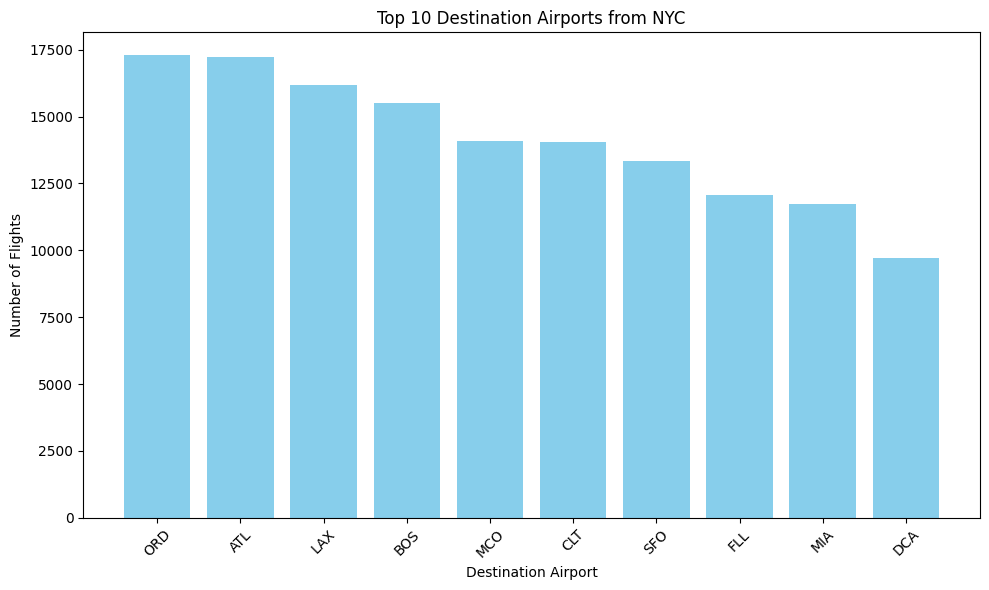

    Carrier  Month  Average Departure Delay
0        9E      1                16.882510
1        9E      2                16.486327
2        9E      3                13.407530
3        9E      4                13.567164
4        9E      5                22.672190
..      ...    ...                      ...
180      YV      8                19.066667
181      YV      9                 8.880952
182      YV     10                20.000000
183      YV     11                10.520833
184      YV     12                13.113636

[185 rows x 3 columns]


In [13]:
import pandas as pd

#part 1.1
#read the file, filter to only flights from NYC's airports
flight_data = pd.read_csv("flight_data.csv")
nyc_flights = flight_data[flight_data['origin'].isin(['JFK', 'LGA', 'EWR'])]

#find the top 10 destinations for flights from nyc
top_destinations = nyc_flights['dest'].value_counts().head(10).reset_index()
#create a table with the destination airports and the number of flights to each
top_destinations.columns = ['Destination Airport', 'Number of Flights']
print(top_destinations)

#part 1.2
import matplotlib.pyplot as plt
#plot the data using matplotlib
plt.figure(figsize=(10, 6))
plt.bar(top_destinations['Destination Airport'], top_destinations['Number of Flights'], color='skyblue')
#create title
plt.title('Top 10 Destination Airports from NYC')
#horizontal axis table
plt.xlabel('Destination Airport')
#vertical axis table
plt.ylabel('Number of Flights')
plt.xticks(rotation=45)
plt.tight_layout()
for index, value in enumerate(top_destinations['Number of Flights']):
    plt.text(index, value, str(value), ha='center', va='bottom')
plt.show()

#part 2.1
#sort flights by carrier and month, calculate the mean of each subset
avg_delay = flight_data.groupby(['carrier', 'month'])['dep_delay'].mean().reset_index()
#add column headings Carrier, Month, Average Departure Delay
avg_delay.columns = ['Carrier', 'Month', 'Average Departure Delay']
print(avg_delay)


### Part 3 - Consistency in On-Time Performance

1. Determine which carrier has the most consistent on-time performance, defined as having the smallest variance in departure delays.

2. Instructions:

    1. Data Cleaning: Ensure that the dataset is cleaned as in Part 1 before performing this analysis.

    2. Variance Calculation: You must **not** use any of the libraries imported above (numpy, pandas, scipy, etc.) for this part. Implement your own function to calculate the variance of departure delays for each carrier.

3. Deliverable

    1. Identify and display the carrier with the smallest variance in departure delays.

    2. Provide a brief explanation of your findings.

In [22]:
# boilerplate for file parsing
import csv
#part 1 cleaning
import pandas as pd
flight_data=pd.read_csv("./flight_data.csv")
rows_with_nulls = flight_data[flight_data.isnull().any(axis=1)]
data = flight_data.dropna()

#variance calculation
def variance(delays):
    mean = sum(delays) / len(delays)
    variance = sum((x - mean) ** 2 for x in delays) / len(delays)
    return variance

#deliverable
# calculate the variance of departure delays for each carrier
def carrier_variance(data):
    carrier_delays = {}
    for _, row in data.iterrows():
        carrier = row['carrier']
        dep_delay = row['dep_delay']
        if carrier not in carrier_delays:
            carrier_delays[carrier] = []
        carrier_delays[carrier].append(dep_delay)
    
    carrier_variances = {carrier: variance(delays) for carrier, delays in carrier_delays.items()}
    return carrier_variances

# identify the carrier with the smallest variance in departure delays
def find_most_consistent_carrier(carrier_variances):
    most_consistent_carrier = min(carrier_variances, key=carrier_variances.get)
    return most_consistent_carrier, carrier_variances[most_consistent_carrier]

carrier_variances = carrier_variance(data)
most_consistent_carrier, smallest_variance = find_most_consistent_carrier(carrier_variances)

print(f"The carrier with the most consistent on-time performance is {most_consistent_carrier} with a variance of {smallest_variance:.2f} in departure delays.")

The carrier with the most consistent on-time performance is US with a variance of 780.55 in departure delays.


(Optional) Check your findings by using the numpy library to preform the same analysis.

In [20]:
import pandas as pd
import numpy as np

#part 1
flight_data = pd.read_csv('./flight_data.csv')
rows_with_nulls = flight_data[flight_data.isnull().any(axis=1)]
data = flight_data.dropna()

#deliverable
#calculate the variance of departure delays for each carrier
def carrier_variance(data):
    carrier_delays = {}
    for _, row in data.iterrows():
        carrier = row['carrier']
        dep_delay = row['dep_delay']
        if carrier not in carrier_delays:
            carrier_delays[carrier] = []
        carrier_delays[carrier].append(dep_delay)

    carrier_variances = {carrier: np.var(delays) for carrier, delays in carrier_delays.items()}
    return carrier_variances

#identify the carrier with the smallest variance in departure delays
def find_most_consistent_carrier(carrier_variances):
    most_consistent_carrier = min(carrier_variances, key=carrier_variances.get)
    return most_consistent_carrier, carrier_variances[most_consistent_carrier]

carrier_variances = carrier_variance(data)
most_consistent_carrier, smallest_variance = find_most_consistent_carrier(carrier_variances)

print(f"The carrier with the most consistent on-time performance is {most_consistent_carrier} with a variance of {smallest_variance:.2f} in departure delays.")

The carrier with the most consistent on-time performance is US with a variance of 780.55 in departure delays.
